<h1><center>IMT2118 - Ciencia de Datos Geoespaciales (2024-1) </center></h1>
<h2><center>Proyecto:   </center></h2>

### Imports

In [2]:
import pandas as pd
import numpy as np 
import geopandas as gpd
import matplotlib.pyplot as plt
import geemap, ee
from shapely.geometry import LineString, Point
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from esda.moran import Moran_Local
from shapely.ops import nearest_points
from sklearn.cluster import DBSCAN
import matplotlib.colors as mcolors
from libpysal.weights import Queen
import geemap.foliumap as geemap
from scipy.spatial import distance_matrix

from shapely import wkt

from shapely.ops import transform
import pyproj

import geopandas as gpd
import pandas as pd
from shapely import wkt

from shapely.ops import transform
import pyproj

from tqdm import tqdm

from warnings import filterwarnings
filterwarnings("ignore")

# Initialize Earth Engine
ee.Authenticate()
ee.Initialize()

### Lectura de Datos

In [3]:
stgo = gpd.read_file("Datos/santiago_urbano.gpkg")
roi_shapely = stgo.union_all()

# Limite Comunal
Limite_Comunal = gpd.read_file("Datos/Limite_Comunal.gpkg")
Limite_Comunal['geometry'] = Limite_Comunal.geometry.intersection(roi_shapely)
Limite_Comunal = Limite_Comunal[~Limite_Comunal.is_empty]

# Zonas
zonas = gpd.read_file("Datos/datosZonas_Stgo_C2017.gpkg")
zonas = zonas.to_crs(Limite_Comunal.crs)

zonas['centroide'] = zonas.geometry.centroid
zonas_centros = zonas.set_geometry('centroide')

zonas_centros = zonas_centros.sjoin(Limite_Comunal[['comuna', 'geometry']], how='left', predicate='within')
zonas['comuna'] = zonas_centros['comuna'].values

## Metro

In [4]:
df = pd.read_csv("Datos/estaciones_metro.csv", decimal=',')

for col in ['stop_lat', 'stop_lon']:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

df['geometry'] = df.apply(lambda row: Point(row['stop_lon'], row['stop_lat']), axis=1)

gdf_estaciones = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

In [5]:
lineas_metro = gpd.read_file("Datos/lineas_metro.gpkg", layer="lineas")

m = geemap.Map(center=[-33.45, -70.65], zoom=12)

for _, row in lineas_metro.iterrows():
    m.add_gdf(
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326"),
        layer_name=f"Línea {row['linea']}",
        style={"color": row["color"], "weight": 4}
    )
m

In [6]:
Metro = gdf_estaciones.copy()
# Cruce espacial para asignar comuna a cada estación
gdf_estaciones_comunas = gpd.sjoin(gdf_estaciones, Limite_Comunal, how='left', predicate='within')

# Conteo de estaciones por comuna
conteo = gdf_estaciones_comunas['comuna'].value_counts().sort_index()

# Comunas que no tienen ninguna estación
comunas_todas = Limite_Comunal['comuna'].unique()
comunas_sin_metro = set(comunas_todas) - set(conteo.index)

print("Comunas sin estaciones de metro:")
print(sorted(comunas_sin_metro))

Comunas sin estaciones de metro:
['CERRO NAVIA', 'COLINA', 'HUECHURABA', 'LA PINTANA', 'LAMPA', 'LO BARNECHEA', 'LO ESPEJO', 'RENCA', 'VITACURA']


In [7]:
# Crear personas_por_comuna agrupando por nombre de comuna
personas_por_comuna = zonas.groupby('comuna')['PERSONAS'].sum()

# Filtrar las comunas sin metro en personas_por_comuna
personas_sin_metro = personas_por_comuna[personas_por_comuna.index.isin(comunas_sin_metro)]
print(personas_sin_metro)
print(f"Total de personas en comunas sin metro: {personas_sin_metro.sum()}")

comuna
CERRO NAVIA     124823
HUECHURABA       74155
LA PINTANA      176832
LAMPA              135
LO BARNECHEA     89948
LO ESPEJO        99328
RENCA           123865
VITACURA         88125
Name: PERSONAS, dtype: int64
Total de personas en comunas sin metro: 777211


## Densidad Poblacional

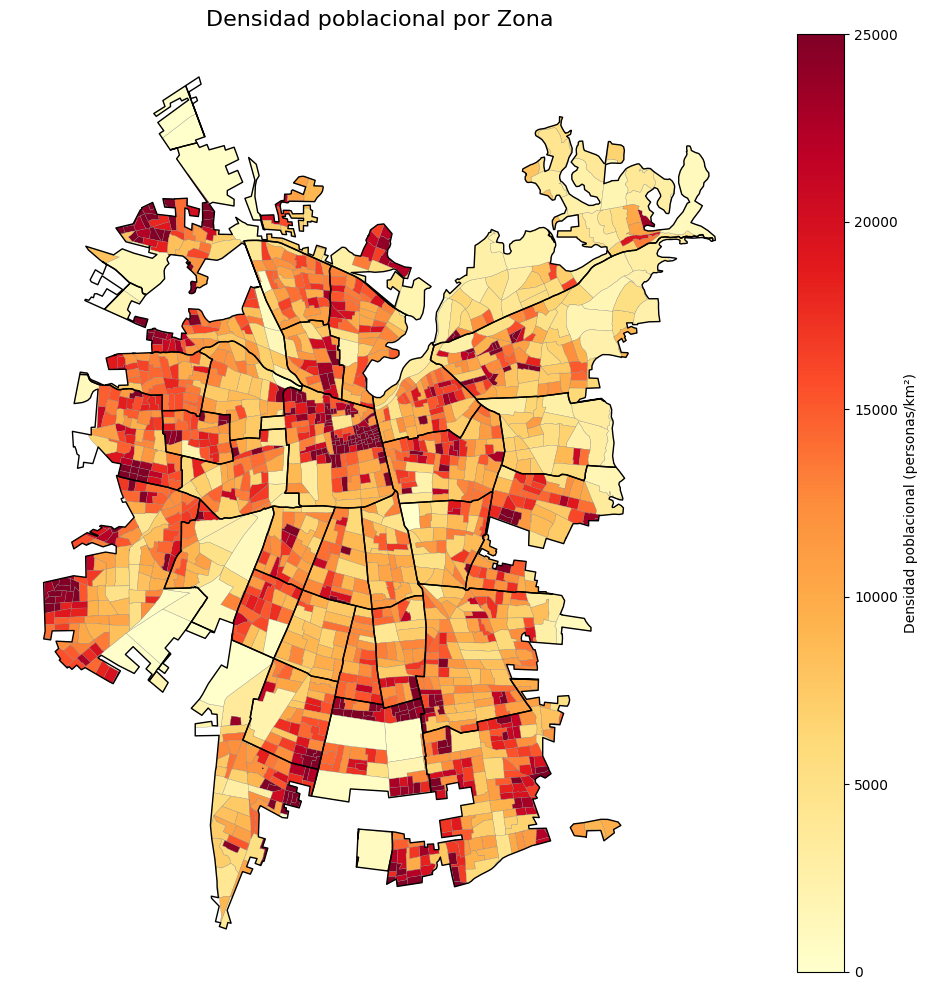

In [8]:
zonas_proj = zonas.to_crs(epsg=32719)
zonas['area_km2'] = zonas_proj.geometry.area / 1e6

zonas['densidad'] = zonas['PERSONAS'] / zonas['area_km2']

fig, ax = plt.subplots(figsize=(10, 10))

vmax = 25000

zonas.plot(
    column='densidad', ax=ax, cmap='YlOrRd', legend=True, 
    legend_kwds={'label': "Densidad poblacional (personas/km²)"},
    edgecolor='gray', linewidth=0.2, vmax=vmax)

Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title('Densidad poblacional por Zona', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

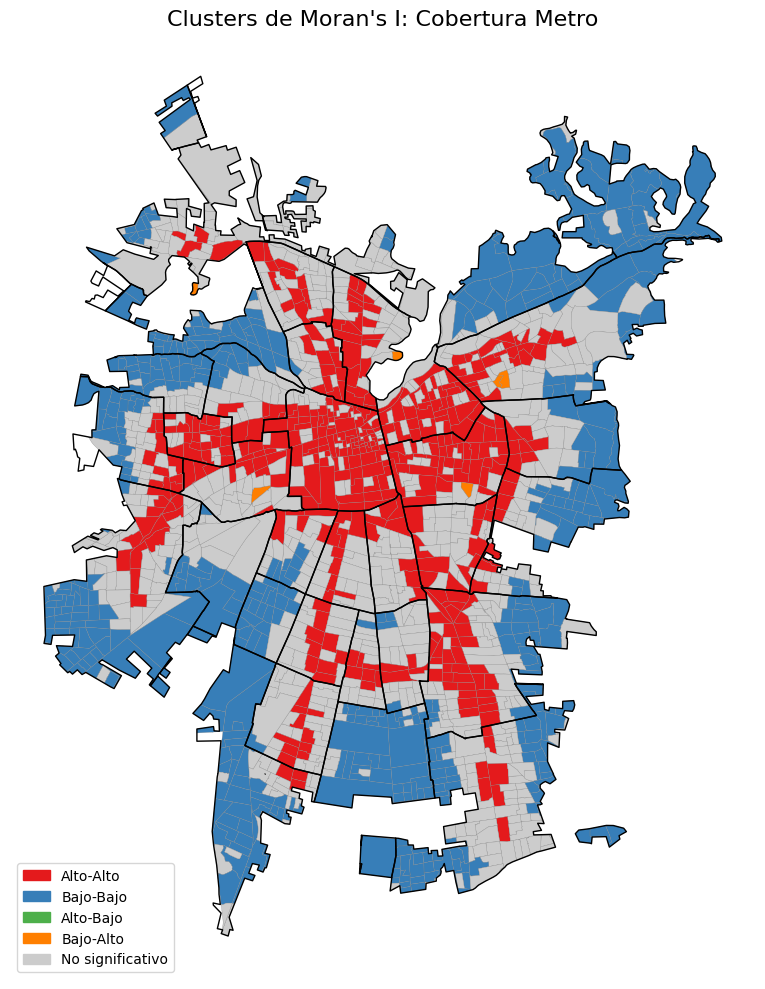

In [9]:
# Crear buffer de 1 km alrededor de las estaciones de metro
gdf_estaciones_proj = gdf_estaciones.to_crs(epsg=32719)
buffer_1km = gdf_estaciones_proj.buffer(1000)
buffer_1km_union = buffer_1km.unary_union

# Volver a WGS84 para intersectar con zonas
project_back = pyproj.Transformer.from_crs(32719, 4326, always_xy=True).transform
buffer_1km_wgs = gpd.GeoSeries([transform(project_back, buffer_1km_union)], crs="EPSG:4326")

zonas['cerca_metro'] = zonas.geometry.intersects(buffer_1km_wgs.iloc[0]).astype(int)

w_zonas = Queen.from_dataframe(zonas)


moran_local_metro = Moran_Local(zonas['cerca_metro'], w_zonas)

zonas['cluster_metro'] = 'No significativo'
zonas.loc[(moran_local_metro.q == 1) & (moran_local_metro.p_sim < 0.05), 'cluster_metro'] = 'Alto-Alto'
zonas.loc[(moran_local_metro.q == 2) & (moran_local_metro.p_sim < 0.05), 'cluster_metro'] = 'Bajo-Alto'
zonas.loc[(moran_local_metro.q == 3) & (moran_local_metro.p_sim < 0.05), 'cluster_metro'] = 'Bajo-Bajo'
zonas.loc[(moran_local_metro.q == 4) & (moran_local_metro.p_sim < 0.05), 'cluster_metro'] = 'Alto-Bajo'

cluster_colors = {
    'Alto-Alto': '#e41a1c',
    'Bajo-Bajo': '#377eb8',
    'Alto-Bajo': '#4daf4a',
    'Bajo-Alto': '#ff7f00',
    'No significativo': '#cccccc'
}

fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, color=zonas['cluster_metro'].map(cluster_colors), edgecolor='gray', linewidth=0.2)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Clusters de Moran's I: Cobertura Metro", fontsize=16)
ax.axis('off')

legend_patches = [mpatches.Patch(color=color, label=label) for label, color in cluster_colors.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

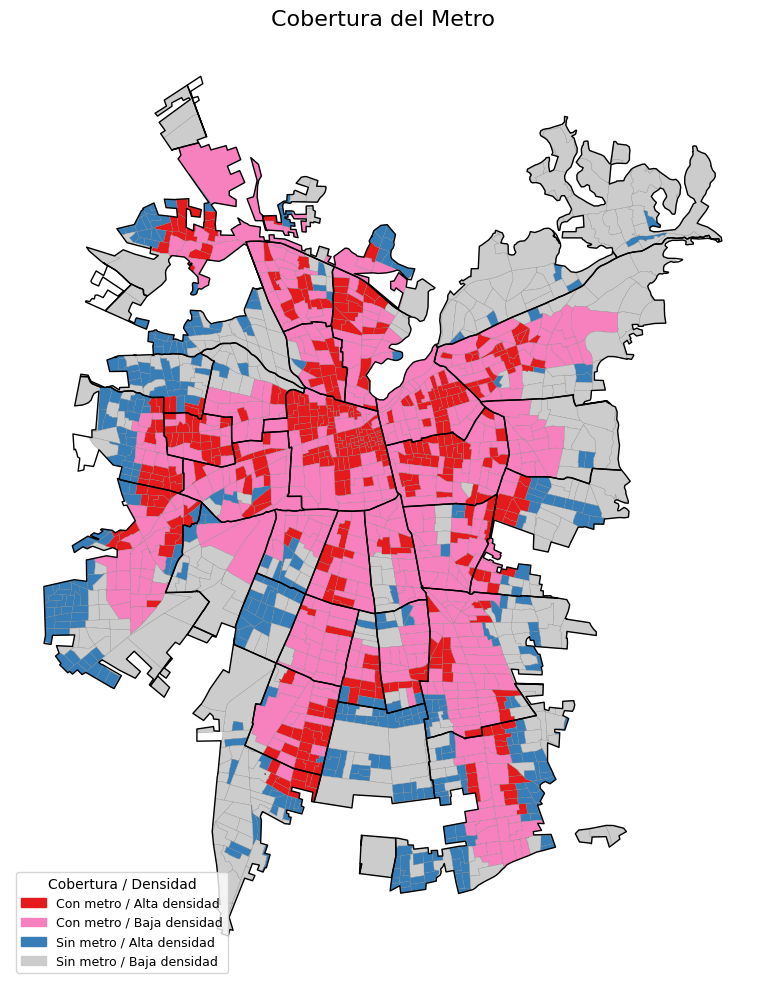

In [10]:
zonas['dens_q'] = pd.qcut(zonas['densidad'], 2, labels=['Baja densidad', 'Alta densidad'])
zonas['metro_q'] = zonas['cerca_metro'].map({0: 'Sin metro', 1: 'Con metro'})
zonas['combo'] = zonas['metro_q'].astype(str) + " / " + zonas['dens_q'].astype(str)

# Paleta de colores combinada
palette_combo = {
    'Con metro / Alta densidad': '#e41a1c',
    'Con metro / Baja densidad': '#f781bf',
    'Sin metro / Alta densidad': '#377eb8',
    'Sin metro / Baja densidad': '#cccccc'
}

fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, color=zonas['combo'].map(palette_combo), edgecolor='gray', linewidth=0.2)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Cobertura del Metro", fontsize=16)
ax.axis('off')

legend_patches = [mpatches.Patch(color=color, label=label) for label, color in palette_combo.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, title='Cobertura / Densidad')

plt.tight_layout()
plt.show()

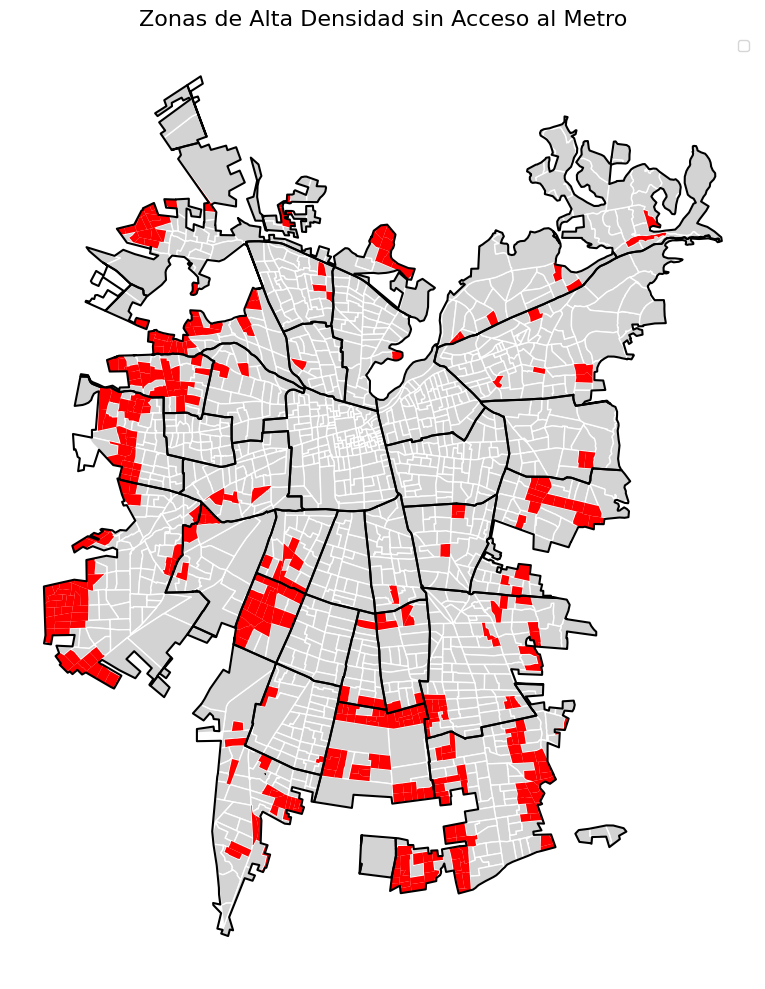

In [11]:
# Zonas alta densidad sin cobertura de metro
zonas['centroide'] = zonas.geometry.centroid
zonas_criticas = zonas[(zonas['dens_q'] == 'Alta densidad') & (zonas['cerca_metro'] == 0)]

fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='white')
zonas_criticas.plot(ax=ax, color='red', markersize=30, label='Alta densidad sin cobertura')
Limite_Comunal.boundary.plot(ax=ax, color='black')

ax.set_title("Zonas de Alta Densidad sin Acceso al Metro", fontsize=16)
ax.legend()
ax.axis('off')
plt.tight_layout()
plt.show()


In [12]:
# Calcular la cantidad total de personas en zonas de alta densidad sin metro
total_personas_zonas_criticas = zonas_criticas['PERSONAS'].sum()
print(f"Cantidad de personas en zonas de alta densidad sin metro: {total_personas_zonas_criticas}")

Cantidad de personas en zonas de alta densidad sin metro: 1520095


In [13]:
# Proyectar a coordenadas en metros (por ejemplo, EPSG:32719)
zonas_criticas_proj = zonas_criticas.to_crs(epsg=32719)
zonas_criticas_proj['x'] = zonas_criticas_proj.geometry.centroid.x
zonas_criticas_proj['y'] = zonas_criticas_proj.geometry.centroid.y

coords = zonas_criticas_proj[['x', 'y']].values

# eps=1000 significa 1 km, ajusta según lo que consideres razonable
db = DBSCAN(eps=1000, min_samples=2).fit(coords)
zonas_criticas['cluster_id'] = db.labels_

In [14]:
# Asegurarse de que zonas_criticas_proj tenga la columna 'cluster_id'
if 'cluster_id' not in zonas_criticas_proj.columns:
	zonas_criticas_proj['cluster_id'] = db.labels_

# Calcular la suma de personas por cluster
cluster_personas = zonas_criticas.groupby('cluster_id')['PERSONAS'].sum().sort_values(ascending=False)

# Crear un diccionario de mapeo: cluster_id original -> nuevo cluster_id ordenado
cluster_id_map = {old: new for new, old in enumerate(cluster_personas.index)}

# Reasignar los cluster_id en zonas_criticas y zonas_criticas_proj, rellenando NaN con -1 (ruido)
zonas_criticas['cluster_id'] = zonas_criticas['cluster_id'].map(cluster_id_map).fillna(-1).astype(int)
zonas_criticas_proj['cluster_id'] = zonas_criticas_proj['cluster_id'].map(cluster_id_map).fillna(-1).astype(int)

In [15]:
# Total de zonas y población
total_zonas = len(zonas)
total_poblacion = zonas['PERSONAS'].sum()

# Zonas cubiertas y no cubiertas
cubiertas = zonas[zonas['cerca_metro'] == 1]
no_cubiertas = zonas[zonas['cerca_metro'] == 0]

n_cubiertas = len(cubiertas)
n_no_cubiertas = len(no_cubiertas)

pob_cubierta = cubiertas['PERSONAS'].sum()
pob_no_cubierta = no_cubiertas['PERSONAS'].sum()

# Porcentaje de población cubierta
porcentaje_cubierta = pob_cubierta / total_poblacion * 100
porcentaje_no_cubierta = pob_no_cubierta / total_poblacion * 100

print(pob_cubierta, f"          ", pob_no_cubierta)
print(porcentaje_cubierta, porcentaje_no_cubierta)

3201628            2665195
54.57175033233489 45.428249667665106


In [16]:
dens_cubiertas = cubiertas['densidad'].mean()
dens_no_cubiertas = no_cubiertas['densidad'].mean()

comunas_excluidas = no_cubiertas.groupby('comuna')['PERSONAS'].sum().sort_values(ascending=False)
top_comunas = comunas_excluidas.head(3)
top_comunas


comuna
PUENTE ALTO     364543
MAIPU           264833
SAN BERNARDO    198646
Name: PERSONAS, dtype: int64

In [17]:
# Asegurarse de que ambos estén en la misma proyección métrica para medir distancias (por ejemplo, EPSG:32719)
no_cubiertas_proj = no_cubiertas.copy().to_crs(epsg=32719)
gdf_estaciones_proj = gdf_estaciones.to_crs(epsg=32719)

# Obtener los centroides de las zonas no cubiertas
centroides = no_cubiertas_proj.geometry.centroid

# Crear un array de puntos de estaciones de metro
estaciones_points = gdf_estaciones_proj.geometry.unary_union

# Calcular la distancia mínima de cada zona no cubierta a una estación de metro
no_cubiertas_proj['dist_estacion_km'] = centroides.apply(lambda x: x.distance(nearest_points(x, estaciones_points)[1]) / 1000)

# Calcular el promedio
dist_promedio = no_cubiertas_proj['dist_estacion_km'].mean()
print(f"Distancia promedio a la estación de metro más cercana para Zonas no cubiertas: {dist_promedio:.2f} km")


Distancia promedio a la estación de metro más cercana para Zonas no cubiertas: 2.70 km


In [18]:
zonas['cluster_metro'].value_counts()

cluster_metro
No significativo    726
Bajo-Bajo           459
Alto-Alto           426
Bajo-Alto             6
Name: count, dtype: int64

## Imagenes Satelitales

In [19]:
gran_santiago = ee.Geometry.Polygon([
    [[-70.9, -33.8], [-70.9, -33.2], [-70.3, -33.2], [-70.3, -33.8]]
])

def mask_s2_sr_clouds(image):
    cloud_prob = image.select('MSK_CLDPRB')
    cloud_mask = cloud_prob.lt(20)
    return image.updateMask(cloud_mask).copyProperties(image, ["system:time_start"])

def get_annual_composite(year):
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(start_date, end_date)
        .filterBounds(gran_santiago)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2_sr_clouds)
    )
    count = collection.size().getInfo()
    if count == 0:
        print(f"No hay imágenes para el año {year}")
        return None
    return collection.median().clip(gran_santiago)

def ndvi(image):
    return image.normalizedDifference(['B8', 'B4']).rename('NDVI')

def ndbi(image):
    return image.normalizedDifference(['B11', 'B8']).rename('NDBI')

def get_ndvi_ndbi(year):
    img = get_annual_composite(year)
    if img:
        return img.addBands(ndvi(img)).addBands(ndbi(img))
    return None
    


In [20]:
img_2019 = get_ndvi_ndbi(2019)
img_2024 = get_ndvi_ndbi(2024)

ndvi_diff = img_2024.select('NDVI').subtract(img_2019.select('NDVI')).rename('NDVI_Diff')
ndbi_diff = img_2024.select('NDBI').subtract(img_2019.select('NDBI')).rename('NDBI_Diff')
diff_stack = ndvi_diff.addBands(ndbi_diff)

In [21]:
limite_comunal_ee = geemap.geopandas_to_ee(Limite_Comunal)

zonales_comunas = diff_stack.reduceRegions(
    collection=limite_comunal_ee,
    reducer=ee.Reducer.mean(),
    scale=30
)



Map = geemap.Map(center=[-33.45, -70.65], zoom=11)

vis_params = {
    'min': -0.5,
    'max': 0.5,
    'palette': [
        '006837', '1a9850', '66bd63', 'ffffbf', 'f46d43', 'd73027', 'a50026'
    ]
}

Map.addLayer(ndbi_diff, vis_params, 'Cambio NDBI 2019–2024')
Map.add_gdf(Limite_Comunal.boundary, layer_name='Límites comunales', style={'color': 'white', 'weight': 1.5})
Map.addLayerControl()
Map


Vemos que mayoritariamente, el desarrollo urbano tiene tendencia hacia las afueras de santiago, puede afectar los años de estudio, que son años de estallido social y pandemia, entonces puede ser una idea importante no centrar el transporte en la zona central o ya urbanizada de santiago, si no que expandir el transporte publico, para tener un mejor acceso a comunas como Colina, Lampa, Buin, Peñaflor y notori

In [22]:
def get_viirs_annual_mean(year):
    collection = (
        ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .select('avg_rad')
        .filterBounds(gran_santiago)
    )
    return collection.mean().clip(gran_santiago)

viirs_2018 = get_viirs_annual_mean(2017)
viirs_2024 = get_viirs_annual_mean(2024)

viirs_diff = viirs_2024.subtract(viirs_2018).rename('DIF_VIIRS')


viirs_vis = {
    'min': -5,
    'max': 20,
    'palette': ['000000', '440154', '31688e', '35b779', 'fde725']
}

Map = geemap.Map(center=[-33.45, -70.65], zoom=11)
Map.addLayer(viirs_diff, viirs_vis, 'Cambio Iluminación Nocturna (2018–2024)')
Map.add_gdf(Limite_Comunal.boundary, layer_name='Límites comunales', style={'color': 'white', 'weight': 1.5})
Map.addLayerControl()
Map



In [23]:
zonales_viirs_comuna = viirs_diff.reduceRegions(
    collection=limite_comunal_ee,
    reducer=ee.Reducer.mean(),
    scale=500
)

## Nuevas Lineas

In [24]:
lineas_metro = gpd.read_file("Datos/nuevas_lineas_metro.gpkg", layer="lineas")

# Crear mapa centrado en Santiago
m = geemap.Map(center=[-33.45, -70.65], zoom=12)

# Agregar cada línea al mapa con su color y estilo
for _, row in lineas_metro.iterrows():
    m.add_gdf(
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326"),
        layer_name=f"Línea {row['linea']}",
        style={"color": row["color"], "weight": 4}
    )

m

In [ ]:
# --- 1. Leer estaciones actuales
df_act = pd.read_csv("Datos/estaciones_metro.csv", decimal=',')

# Asegurar coordenadas tipo float   
for col in ['stop_lat', 'stop_lon']:
    df_act[col] = df_act[col].astype(str).str.replace(',', '.').astype(float)

df_act['geometry'] = df_act.apply(lambda row: Point(row['stop_lon'], row['stop_lat']), axis=1)
gdf_actuales = gpd.GeoDataFrame(df_act, geometry='geometry', crs="EPSG:4326")

# Leer nuevas estaciones
df_nuevas = pd.read_csv("Datos/nuevas_estaciones.csv")

# --- Reparar geometrías inválidas ---
def cargar_o_reparar_geom(row):
    val = row['geometry']
    stop_id = row['stop_id']
    try:
        if isinstance(val, str) and val.startswith("POINT") and "None" not in val:
            return wkt.loads(val)
    except:
        pass

    # Si falla o es "None", buscamos en estaciones actuales
    match = df_act[df_act['stop_id'] == stop_id]
    if not match.empty:
        return match.iloc[0]['geometry']
    
    return None  # Si no la encontramos, queda como None

df_nuevas['geometry'] = df_nuevas.apply(cargar_o_reparar_geom, axis=1)
gdf_nuevas = gpd.GeoDataFrame(df_nuevas, geometry='geometry', crs="EPSG:4326")

# Eliminar estaciones sin geometría válida
gdf_nuevas = gdf_nuevas[~gdf_nuevas['geometry'].isna()].copy()

# Unir actuales + nuevas
gdf_total = pd.concat([gdf_actuales, gdf_nuevas], ignore_index=True)
gdf_total = gdf_total.drop_duplicates(subset=['stop_id'])  # evita duplicados por ID
df_nuevas = gpd.GeoDataFrame(df_nuevas, geometry='geometry', crs="EPSG:4326")

# --- 3. Unir actuales + nuevas
gdf_total = pd.concat([gdf_actuales, gdf_nuevas], ignore_index=True)
gdf_total = gdf_total.drop_duplicates(subset=['geometry'])  # eliminar posibles duplicados

# --- 4. Asignar comuna a cada estación
gdf_sjoin_total = gpd.sjoin(gdf_total, Limite_Comunal, how='left', predicate='within')
gdf_sjoin_actual = gpd.sjoin(gdf_actuales, Limite_Comunal, how='left', predicate='within')

# --- 5. Obtener sets de comunas con estaciones
comunas_total = set(gdf_sjoin_total['comuna'].dropna())
comunas_actual = set(gdf_sjoin_actual['comuna'].dropna())
comunas_todas = set(Limite_Comunal['comuna'])

# --- 6. Comunas sin estaciones (antes y después)
comunas_sin_metro_actual = comunas_todas - comunas_actual
comunas_sin_metro_nuevo  = comunas_todas - comunas_total

print("Comunas sin estaciones (actual):", sorted(comunas_sin_metro_actual))
print("Comunas sin estaciones (nuevo):", sorted(comunas_sin_metro_nuevo))

# --- 7. ¿Qué comunas ganan cobertura?
comunas_que_ganan = comunas_sin_metro_actual - comunas_sin_metro_nuevo
print("\nComunas que ganan estaciones:", sorted(comunas_que_ganan))

# --- 8. Población afectada (usando zonas con personas)
personas_por_comuna = zonas.groupby('comuna')['PERSONAS'].sum()

# Población sin metro (antes)
personas_sin_metro_actual = personas_por_comuna[personas_por_comuna.index.isin(comunas_sin_metro_actual)].sum()
# Población sin metro (nuevo)
personas_sin_metro_nuevo  = personas_por_comuna[personas_por_comuna.index.isin(comunas_sin_metro_nuevo)].sum()
# Población beneficiada
personas_beneficiadas = personas_sin_metro_actual - personas_sin_metro_nuevo

print(f"\nTotal personas en comunas sin metro (actual): {personas_sin_metro_actual:,}")
print(f"Total personas en comunas sin metro (nuevo): {personas_sin_metro_nuevo:,}")
print(f"Personas beneficiadas por nuevas estaciones: {personas_beneficiadas:,}")


Comunas sin estaciones (actual): ['CERRO NAVIA', 'COLINA', 'HUECHURABA', 'LA PINTANA', 'LAMPA', 'LO BARNECHEA', 'LO ESPEJO', 'RENCA', 'VITACURA']
Comunas sin estaciones (nuevo): ['COLINA', 'HUECHURABA', 'LAMPA', 'LO BARNECHEA']

Comunas que ganan estaciones: ['CERRO NAVIA', 'LA PINTANA', 'LO ESPEJO', 'RENCA', 'VITACURA']

Total personas en comunas sin metro (actual): 777,211
Total personas en comunas sin metro (nuevo): 164,238
Personas beneficiadas por nuevas estaciones: 612,973


In [26]:
# --- 1. Transformar a proyección métrica para calcular buffer
gdf_total_proj = gdf_total.to_crs(epsg=32719)  # UTM zona 19 Sur
buffer_1km_total = gdf_total_proj.buffer(1000)
buffer_union_total = buffer_1km_total.unary_union

# --- 2. Transformar de vuelta a WGS84
project_back = pyproj.Transformer.from_crs(32719, 4326, always_xy=True).transform
buffer_1km_total_wgs = gpd.GeoSeries([transform(project_back, buffer_union_total)], crs="EPSG:4326")

# --- 3. Intersectar con zonas
zonas['cerca_metro_nuevo'] = zonas.geometry.intersects(buffer_1km_total_wgs.iloc[0]).astype(int)

# --- 4. Comparar con cobertura anterior
zonas['gana_cobertura'] = ((zonas['cerca_metro'] == 0) & (zonas['cerca_metro_nuevo'] == 1)).astype(int)

# --- 5. Personas beneficiadas en zonas ganadoras
personas_beneficiadas_zonas = zonas.loc[zonas['gana_cobertura'] == 1, 'PERSONAS'].sum()
print(f"Personas beneficiadas por nuevas estaciones (por zona): {personas_beneficiadas_zonas:,}")

Personas beneficiadas por nuevas estaciones (por zona): 971,599


## Test Zone

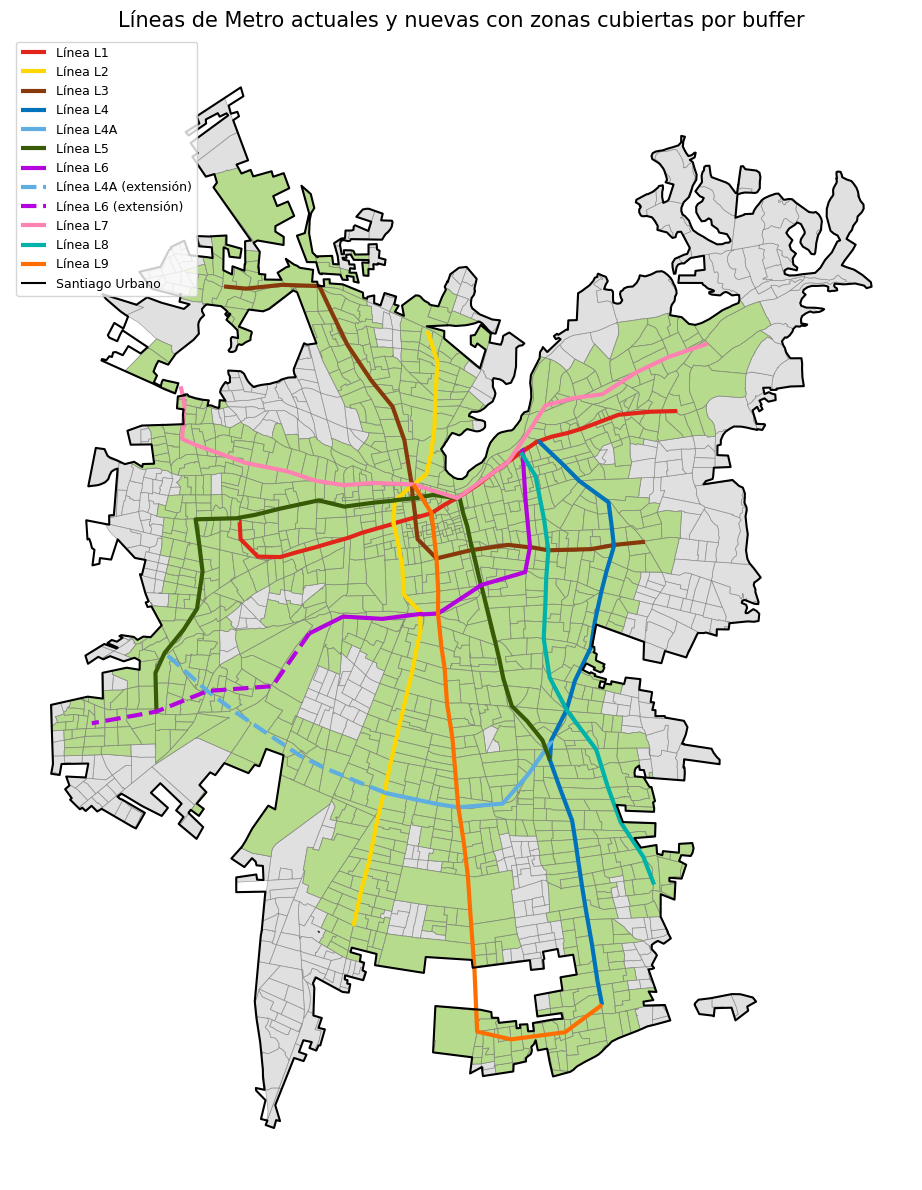

In [28]:
from shapely import wkt

fig, ax = plt.subplots(figsize=(12, 12))

# Dibujar todas las zonas en gris claro
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='gray', linewidth=0.5, alpha=0.7, label='Zonas')

# Zonas cubiertas por el buffer de estaciones nuevas
zonas_cubiertas = zonas[zonas['cerca_metro_nuevo'] == 1]
zonas_cubiertas.plot(ax=ax, color='#a6d96a', edgecolor='gray', linewidth=0.5, alpha=0.7, label='Zonas cubiertas (buffer)')

# Líneas actuales
lineas_actuales = gpd.read_file("Datos/lineas_metro.gpkg", layer="lineas")
for _, row in lineas_actuales.iterrows():
    label = f"Línea {row['linea']}"
    row_gdf = gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326")
    row_gdf.plot(ax=ax, color=row["color"], linewidth=3, label=label)

# Líneas nuevas (incluyendo extensiones)
lineas_nuevas = gpd.read_file("Datos/nuevas_lineas_metro.gpkg", layer="lineas")
for _, row in lineas_nuevas.iterrows():
    linea = row["linea"]
    color = row["color"]
    row_gdf = gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326")
    if linea in ["L6", "L4A"]:
        row_gdf.plot(ax=ax, color=color, linewidth=3, linestyle="--", label=f"Línea {linea} (extensión)")
    else:
        row_gdf.plot(ax=ax, color=color, linewidth=3, label=f"Línea {linea}")


df_nuevas['geometry'] = df_nuevas.apply(cargar_o_reparar_geom, axis=1)
gdf_nuevas = gpd.GeoDataFrame(df_nuevas, geometry='geometry', crs="EPSG:4326")
gdf_nuevas = gdf_nuevas[~gdf_nuevas['geometry'].isna()].copy()

# Limite comunal
stgo.boundary.plot(ax=ax, color='black', linewidth=1.5, label='Santiago Urbano')

ax.set_title("Líneas de Metro actuales y nuevas con zonas cubiertas por buffer", fontsize=15)
ax.axis('off')

# Eliminar labels duplicados en la leyenda
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

Reduciendo zonas en EE: 100%|██████████| 17/17 [01:47<00:00,  6.32s/it]


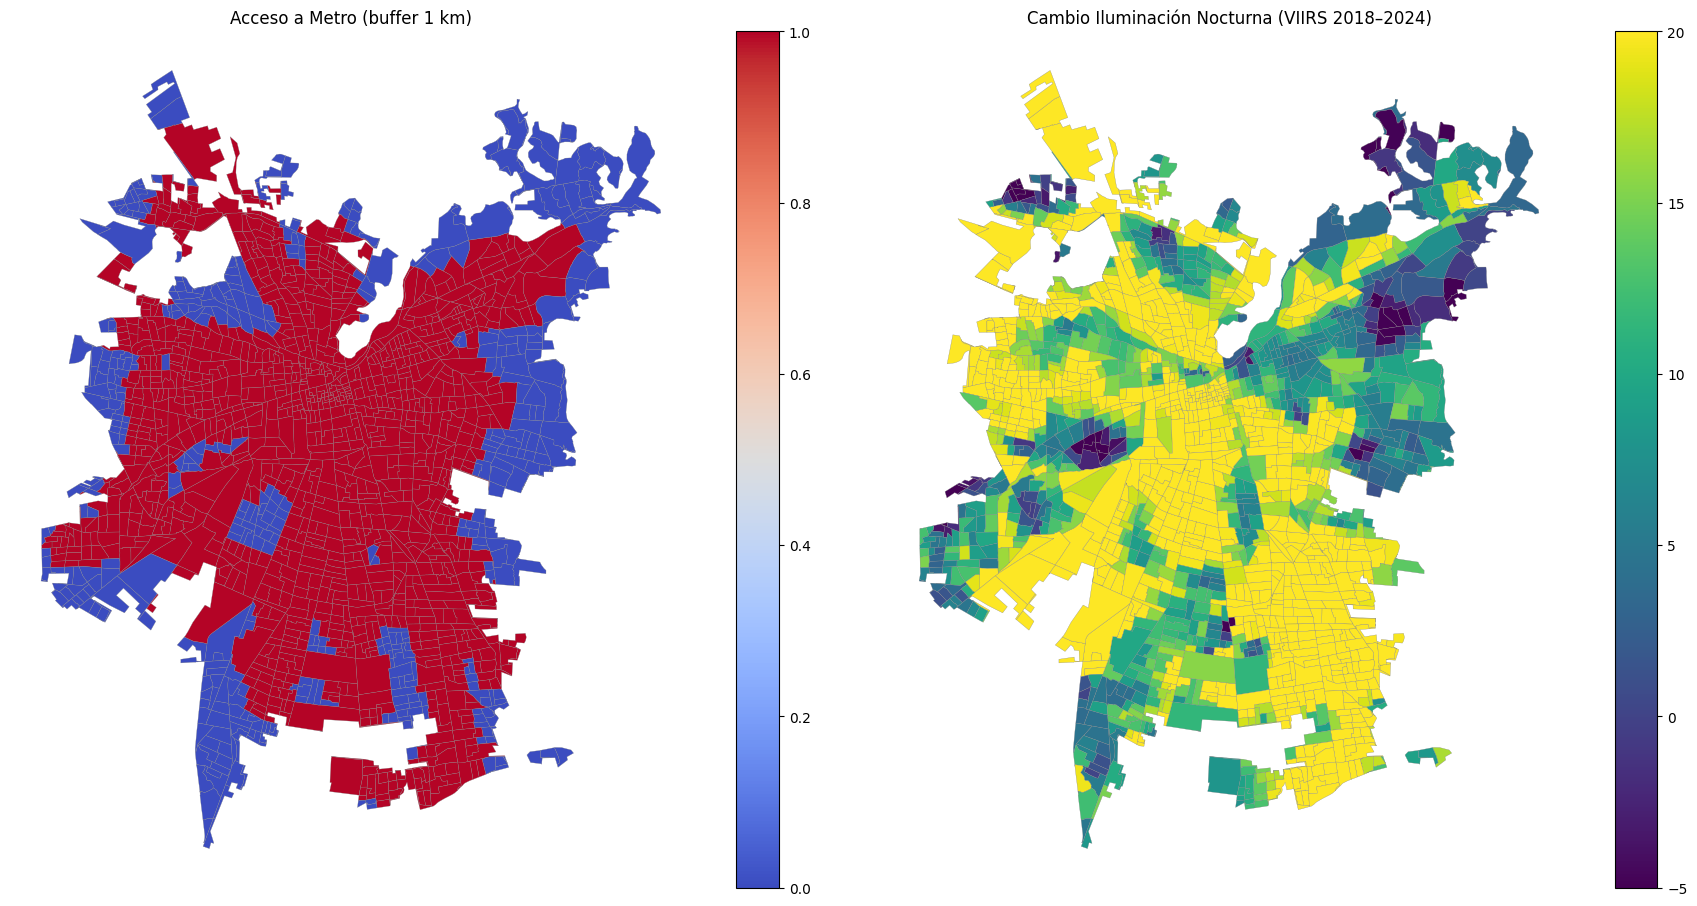

In [29]:
from shapely.geometry.base import BaseGeometry

zonas = zonas.set_geometry('geometry')

# Eliminar columnas de geometría extra (como centroide)
zonas = zonas[[col for col in zonas.columns if not isinstance(zonas[col].iloc[0], BaseGeometry) or col == zonas.geometry.name]]

# Simplificar geometrías para reducir peso
#zonas['geometry'] = zonas.geometry.simplify(tolerance=50, preserve_topology=True)

# 2. Dividir en bloques y reducir en Earth Engine
bloques = [zonas.iloc[i:i+100] for i in range(0, len(zonas), 100)]
resultados = []

for bloque in tqdm(bloques, desc="Reduciendo zonas en EE"):
    bloque_ee = geemap.geopandas_to_ee(bloque)
    viirs_parcial = viirs_diff.reduceRegions(
        collection=bloque_ee,
        reducer=ee.Reducer.mean(),
        scale=500
    ).getInfo()
    resultados.extend(viirs_parcial['features'])

# 3. Asociar valores promedio a cada zona
viirs_mean_by_zona = {
    f['properties']['NZONA']: f['properties']['mean']
    for f in resultados if 'NZONA' in f['properties'] and 'mean' in f['properties']
}
zonas['viirs_diff_mean'] = zonas['NZONA'].map(viirs_mean_by_zona)

# 4. Visualización comparativa
fig, ax = plt.subplots(1, 2, figsize=(18, 9))

if zonas.crs.to_epsg() != 4326:
    zonas = zonas.to_crs(epsg=4326)
# Acceso a metro
zonas.plot(
    column='cerca_metro_nuevo',
    cmap='coolwarm',
    legend=True,
    ax=ax[0],
    edgecolor='gray',
    linewidth=0.2
)
ax[0].set_title('Acceso a Metro (buffer 1 km)')
ax[0].axis('off')

# Iluminación nocturna promedio
zonas.plot(
    column='viirs_diff_mean',
    cmap='viridis',
    legend=True,
    ax=ax[1],
    edgecolor='gray',
    linewidth=0.2,
    vmin=-5, vmax=20
)
ax[1].set_title('Cambio Iluminación Nocturna (VIIRS 2018–2024)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [30]:
sns.lmplot(data=zonas, x='viirs_diff_mean', y='densidad', hue='cerca_metro', markers=['x', 'o'])
plt.title("Iluminación nocturna vs Densidad por acceso a metro")


NameError: name 'sns' is not defined

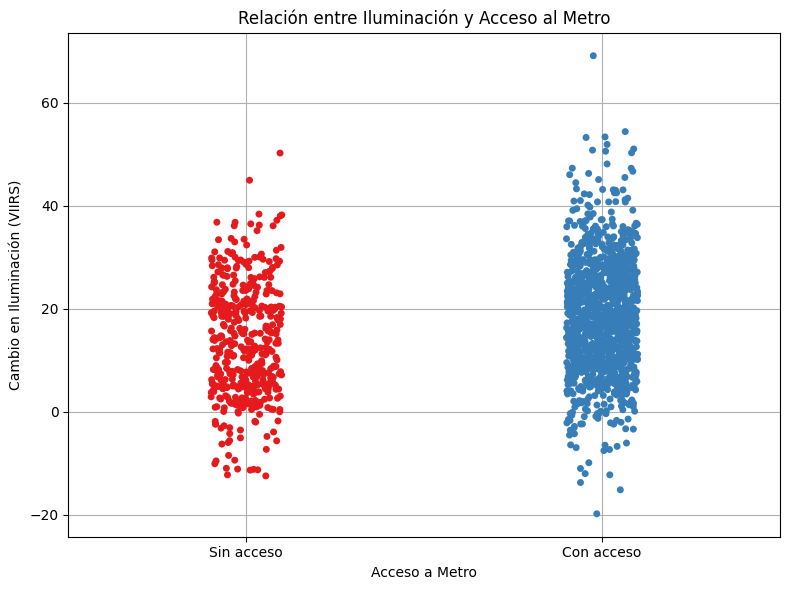

In [ ]:
import seaborn as sns
# Scatterplot: Iluminación vs Acceso a Metro
plt.figure(figsize=(8,6))
sns.stripplot(data=zonas, x='cerca_metro_nuevo', y='viirs_diff_mean', jitter=True, palette='Set1')
plt.xticks([0,1], ['Sin acceso', 'Con acceso'])
plt.xlabel('Acceso a Metro')
plt.ylabel('Cambio en Iluminación (VIIRS)')
plt.title('Relación entre Iluminación y Acceso al Metro')
plt.grid(True)
plt.tight_layout()
plt.show()

Reduciendo Sentinel-2 por zonas: 100%|██████████| 17/17 [22:09<00:00, 78.23s/it]


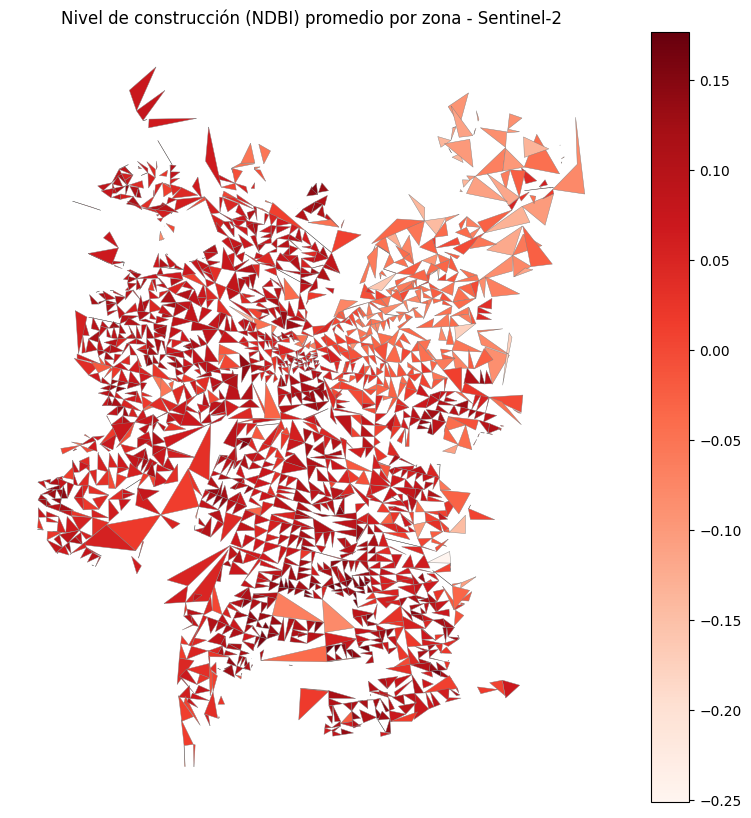

In [ ]:
from shapely.geometry.base import BaseGeometry
from tqdm import tqdm

# 1. Asegura geometría limpia y proyección adecuada
zonas = zonas.set_geometry('geometry')
zonas = zonas[[col for col in zonas.columns if not isinstance(zonas[col].iloc[0], BaseGeometry) or col == zonas.geometry.name]]

# 2. Cargar imagen con NDVI y NDBI de Sentinel-2 para 2023
img = get_ndvi_ndbi(2023)  # o 2018 para comparar

# 3. Dividir zonas en bloques para evitar errores de memoria
bloques = [zonas.iloc[i:i+100] for i in range(0, len(zonas), 100)]
resultados = []

for bloque in tqdm(bloques, desc="Reduciendo Sentinel-2 por zonas"):
    bloque_ee = geemap.geopandas_to_ee(bloque)
    viirs_parcial = img.reduceRegions(
        collection=bloque_ee,
        reducer=ee.Reducer.mean(),
        scale=10
    ).getInfo()
    resultados.extend(viirs_parcial['features'])

# 4. Asociar valores a cada zona
ndvi_dict = {}
ndbi_dict = {}

for f in resultados:
    props = f['properties']
    if 'NZONA' in props:
        ndvi_dict[props['NZONA']] = props.get('NDVI')
        ndbi_dict[props['NZONA']] = props.get('NDBI')

zonas['ndvi_mean'] = zonas['NZONA'].map(ndvi_dict)
zonas['ndbi_mean'] = zonas['NZONA'].map(ndbi_dict)

# 5. Visualización (ejemplo NDBI)
zonas.plot(
    column='ndbi_mean',
    cmap='Reds',
    legend=True,
    figsize=(10, 10),
    edgecolor='gray',
    linewidth=0.3
)
plt.title("Nivel de construcción (NDBI) promedio por zona - Sentinel-2")
plt.axis('off')
plt.show()


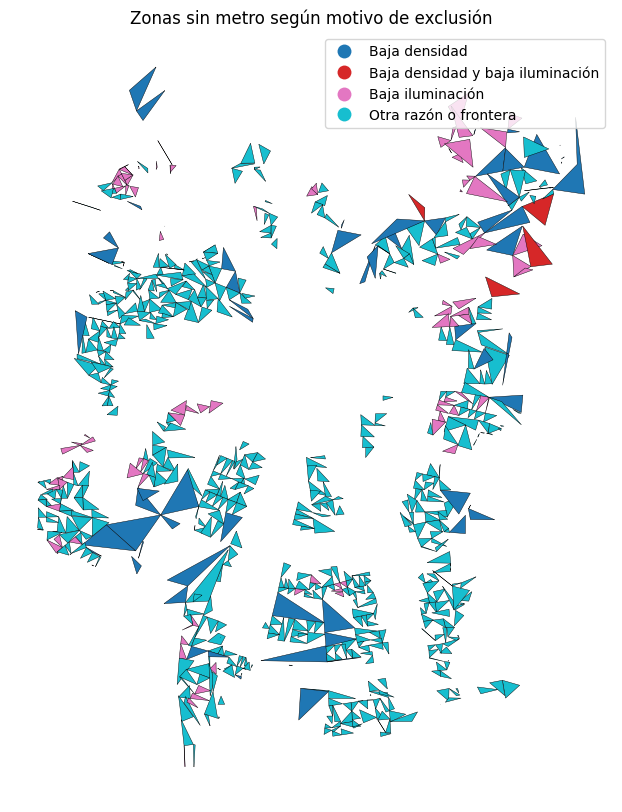

In [ ]:
zonas_sin_metro = zonas[zonas['cerca_metro'] == 0].copy()

zonas.groupby('cerca_metro')[['densidad', 'viirs_diff_mean']].mean()

def motivo_exclusion(row):
    if row['densidad'] < 3000 and row['viirs_diff_mean'] < 3:
        return 'Baja densidad y baja iluminación'
    elif row['densidad'] < 3000:
        return 'Baja densidad'
    elif row['viirs_diff_mean'] < 3:
        return 'Baja iluminación'
    else:
        return 'Otra razón o frontera'

zonas_sin_metro['motivo_exclusion'] = zonas_sin_metro.apply(motivo_exclusion, axis=1)

zonas_sin_metro['motivo_exclusion'].value_counts(normalize=True)

zonas_sin_metro.plot(
    column='motivo_exclusion',
    cmap='tab10',
    legend=True,
    figsize=(10, 10),
    edgecolor='black',
    linewidth=0.3
)
plt.title("Zonas sin metro según motivo de exclusión")
plt.axis('off')
plt.show()


  File "c:\Program Files\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Program Files\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python313\Lib\sub

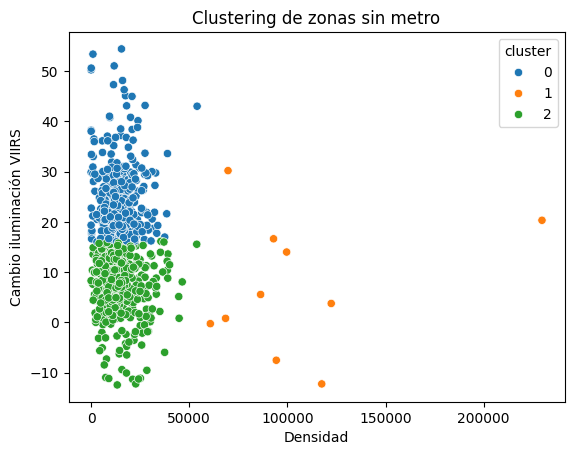

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- 1. Filtrar solo zonas sin metro
df_no_metro = zonas[zonas['cerca_metro'] == 0][['densidad', 'viirs_diff_mean']].dropna()

# --- 2. Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_no_metro)

# --- 3. KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_no_metro['cluster'] = kmeans.fit_predict(X_scaled)

# --- 4. Visualizar
sns.scatterplot(
    data=df_no_metro,
    x='densidad',
    y='viirs_diff_mean',
    hue='cluster',
    palette='tab10'
)
plt.title("Clustering de zonas sin metro")
plt.xlabel("Densidad")
plt.ylabel("Cambio iluminación VIIRS")
plt.show()


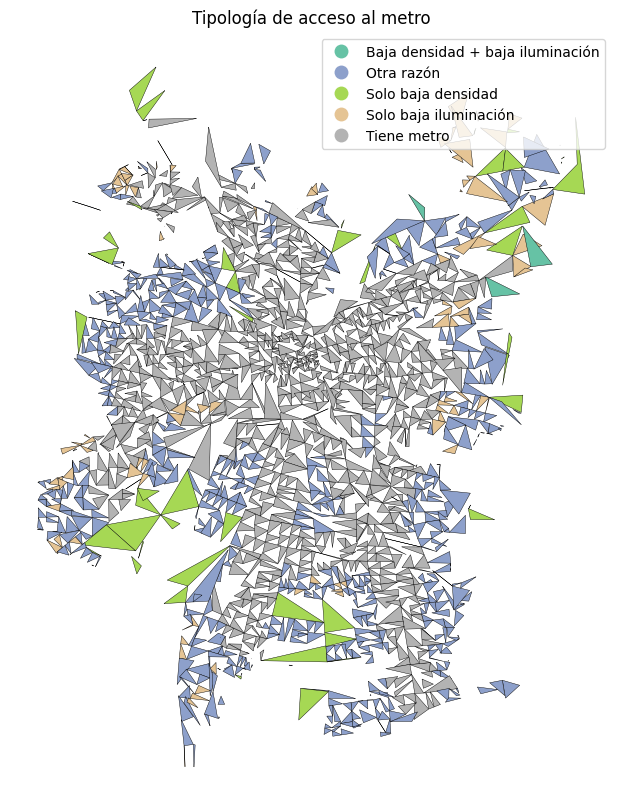

In [ ]:
def motivo_exclusion(row):
    if row['densidad'] < 2500 and row['viirs_diff_mean'] < 3:
        return 'Baja densidad + baja iluminación'
    elif row['densidad'] < 2500:
        return 'Solo baja densidad'
    elif row['viirs_diff_mean'] < 3:
        return 'Solo baja iluminación'
    else:
        return 'Otra razón'

zonas['motivo_exclusion'] = zonas.apply(lambda r: motivo_exclusion(r) if r['cerca_metro'] == 0 else 'Tiene metro', axis=1)

zonas.plot(
    column='motivo_exclusion',
    cmap='Set2',
    legend=True,
    figsize=(12, 10),
    edgecolor='black',
    linewidth=0.3
)
plt.title("Tipología de acceso al metro")
plt.axis('off')
plt.show()


In [ ]:
# Verificar que existen las columnas necesarias
if 'ndbi_mean_2023' not in zonas.columns or 'ndbi_mean_2018' not in zonas.columns:
    raise KeyError("Faltan las columnas 'ndbi_mean_2023' y/o 'ndbi_mean_2018' en el DataFrame 'zonas'. "
                   "Asegúrate de calcular y asignar los valores promedio de NDBI para ambos años antes de calcular la diferencia.")

# Calcular diferencias por zona
zonas['ndbi_diff'] = zonas['ndbi_mean_2023'] - zonas['ndbi_mean_2018']

# Visualizar solo zonas que no tienen metro
zonas_sin_metro = zonas[zonas['cerca_metro'] == 0]

zonas_sin_metro.plot(
    column='ndbi_diff',
    cmap='bwr',
    legend=True,
    figsize=(10, 10),
    edgecolor='gray',
    linewidth=0.3,
    vmin=-0.2, vmax=0.2
)
plt.title("Cambio en nivel de construcción (NDBI) 2018–2023\nZonas sin acceso a metro")
plt.axis('off')
plt.show()


KeyError: "Faltan las columnas 'ndbi_mean_2023' y/o 'ndbi_mean_2018' en el DataFrame 'zonas'. Asegúrate de calcular y asignar los valores promedio de NDBI para ambos años antes de calcular la diferencia."

In [ ]:
agrupado = zonas.groupby('comuna').agg({
    'ndbi_mean': 'mean',
    'ndvi_mean': 'mean',
    'cerca_metro': 'mean',
    'PERSONAS': 'sum'
})

# Agrega columna de cobertura (alta si cobertura < 0.3)
agrupado['sin_metro'] = (agrupado['cerca_metro'] < 0.3).astype(int)

# Ordenar por ndbi alto y sin metro
sin_metro = agrupado[agrupado['sin_metro'] == 1].sort_values('ndbi_mean', ascending=False)
print(sin_metro[['ndbi_mean', 'ndvi_mean', 'PERSONAS']].head(10))


              ndbi_mean  ndvi_mean  PERSONAS
comuna                                      
LA PINTANA     0.112652   0.122137    176832
LO ESPEJO      0.097477   0.117036     99328
CERRO NAVIA    0.095255   0.133722    124823
PUENTE ALTO    0.082960   0.145031    520471
RENCA          0.081452   0.141724    123865
LAMPA          0.075565   0.100389       135
SAN BERNARDO   0.070770   0.153883    246192
CERRILLOS      0.057609   0.161671     83851
VITACURA      -0.053046   0.303959     88125
LO BARNECHEA  -0.055385   0.336803     89948


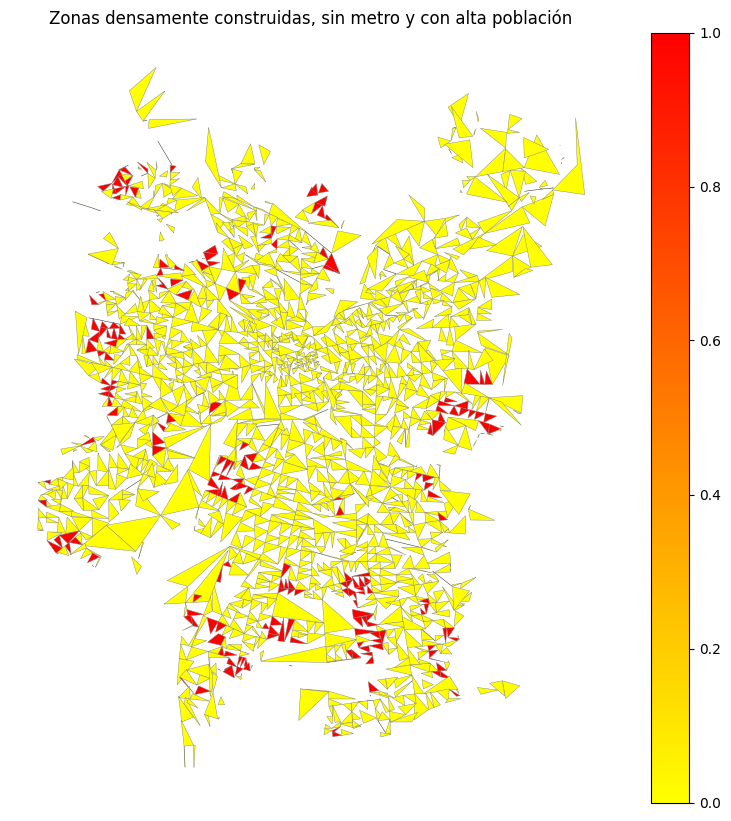

In [ ]:
zonas['condicion_critica'] = (
    (zonas['ndbi_mean'] > 0.08) &
    (zonas['cerca_metro_nuevo'] == 0) &
    (zonas['PERSONAS'] > 2000)
).astype(int)

zonas.plot(
    column='condicion_critica',
    cmap='autumn_r',
    legend=True,
    figsize=(10, 10),
    edgecolor='gray',
    linewidth=0.3
)
plt.title("Zonas densamente construidas, sin metro y con alta población")
plt.axis('off')
plt.show()


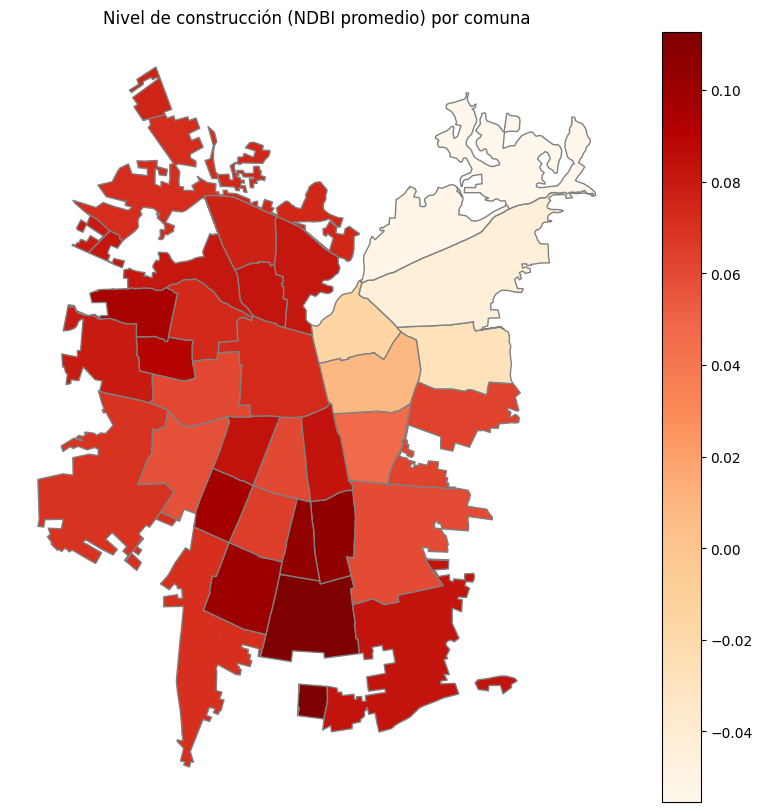

In [ ]:
# Suponiendo que hiciste el join zonas → comuna
comunal = zonas.groupby('comuna').agg({
    'ndbi_mean': 'mean',
    'ndvi_mean': 'mean',
    'PERSONAS': 'sum',
    'cerca_metro': 'mean'
}).reset_index()

Limite_Comunal = Limite_Comunal.merge(comunal, on='comuna', how='left')

Limite_Comunal.plot(
    column='ndbi_mean',
    cmap='OrRd',
    legend=True,
    figsize=(10, 10),
    edgecolor='gray'
)
plt.title("Nivel de construcción (NDBI promedio) por comuna")
plt.axis('off')
plt.show()


## MetroTren


Columnas disponibles en estaciones_metrotren.csv: ['stop_id', 'nombre', 'direccion', 'lat', 'lon', 'stop_code', 'stop_url', 'wheelchair_boarding', 'location_type', 'parent_station', 'geometry']
Personas beneficiadas por estaciones de metrotren (por zona): 1,217,642


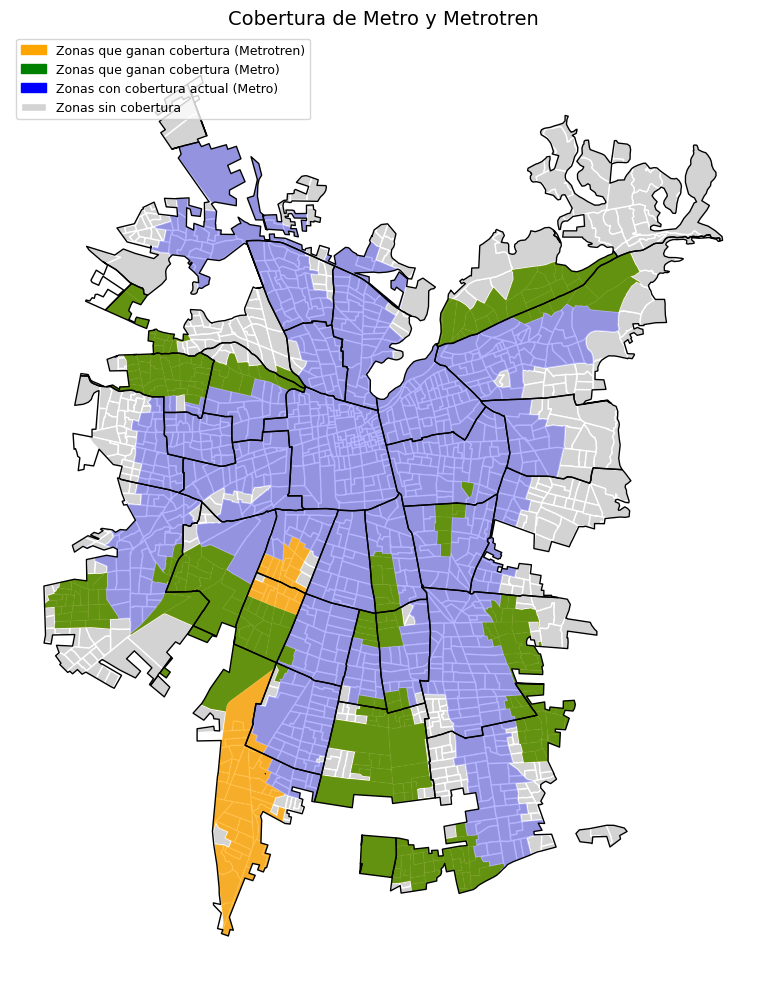

In [ ]:
# Leer estaciones de Metrotren
df_metrotren = pd.read_csv("Datos/estaciones_metrotren.csv", decimal=',')

# Revisar nombres de columnas para encontrar las de latitud y longitud
print("Columnas disponibles en estaciones_metrotren.csv:", df_metrotren.columns.tolist())

# Asumimos que las columnas correctas son 'lat' y 'lon', ajústalas si son diferentes
lat_col = None
lon_col = None
for c in df_metrotren.columns:
    if 'lat' in c.lower():
        lat_col = c
    if 'lon' in c.lower():
        lon_col = c

if lat_col is None or lon_col is None:
    raise ValueError("No se encontraron columnas de latitud/longitud en el archivo CSV.")

# Asegurar coordenadas tipo float
for col in [lat_col, lon_col]:
    df_metrotren[col] = df_metrotren[col].astype(str).str.replace(',', '.').astype(float)

df_metrotren['geometry'] = df_metrotren.apply(lambda row: Point(row[lon_col], row[lat_col]), axis=1)
gdf_metrotren = gpd.GeoDataFrame(df_metrotren, geometry='geometry', crs="EPSG:4326")

# Unir estaciones de metro y metrotren
gdf_total_metrotren = pd.concat([gdf_total, gdf_metrotren], ignore_index=True)
gdf_total_metrotren = gdf_total_metrotren.drop_duplicates(subset=['geometry'])

# Proyección métrica y buffer 1km
gdf_total_metrotren_proj = gdf_total_metrotren.to_crs(epsg=32719)
buffer_1km_total_metrotren = gdf_total_metrotren_proj.buffer(1000)
buffer_union_total_metrotren = buffer_1km_total_metrotren.unary_union

# Volver a WGS84
project_back = pyproj.Transformer.from_crs(32719, 4326, always_xy=True).transform
buffer_1km_total_metrotren_wgs = gpd.GeoSeries([transform(project_back, buffer_union_total_metrotren)], crs="EPSG:4326")

# Revisar ocupación del buffer (zonas cubiertas por metro o metrotren)
zonas['cerca_metro_metrotren'] = zonas.geometry.intersects(buffer_1km_total_metrotren_wgs.iloc[0]).astype(int)
zonas['gana_cobertura_metrotren'] = ((zonas['cerca_metro'] == 0) & (zonas['cerca_metro_metrotren'] == 1)).astype(int)

# Personas beneficiadas por estaciones de metrotren (adicionales)
personas_beneficiadas_metrotren = zonas.loc[zonas['gana_cobertura_metrotren'] == 1, 'PERSONAS'].sum()
print(f"Personas beneficiadas por estaciones de metrotren (por zona): {personas_beneficiadas_metrotren:,}")

# Mapa actualizado
fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='white')
zonas[zonas['gana_cobertura_metrotren'] == 1].plot(ax=ax, color='orange', label='Zonas que ganan cobertura (Metrotren)', alpha=0.8)
zonas[zonas['gana_cobertura'] == 1].plot(ax=ax, color='green', label='Zonas que ganan cobertura (Metro)', alpha=0.6)
zonas[zonas['cerca_metro'] == 1].plot(ax=ax, color='blue', label='Zonas con cobertura actual (Metro)', alpha=0.3)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)


ax.set_title("Cobertura de Metro y Metrotren", fontsize=14)
ax.axis('off')
legend_patches = [
    mpatches.Patch(color='orange', label='Zonas que ganan cobertura (Metrotren)'),
    mpatches.Patch(color='green', label='Zonas que ganan cobertura (Metro)'),
    mpatches.Patch(color='blue', label='Zonas con cobertura actual (Metro)'),
    mpatches.Patch(facecolor='lightgray', edgecolor='white', label='Zonas sin cobertura')
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()